In [1]:
%matplotlib inline


In [2]:
from utils import *

plt.rcParams["figure.figsize"] = (7, 5)


1*q0^1 + (-1*q1^1)i + (-1*q2^1)j + (-1*q3^1)k
1*q0^1 + (1*q1^1)i + (1*q2^1)j + (1*q3^1)k
0*q0^1q3^1 + 0*q1^1q3^1 + 0*q2^1q3^1 + (1*q1^2 + 2*q1^1q2^1 + 2*q1^1q3^1 + 1*q0^2 + 2*q0^1q2^1 + -2*q0^1q3^1 + -1*q3^2 + -1*q2^2)i + (2*q1^1q2^1 + 1*q2^2 + 2*q2^1q3^1 + 1*q0^2 + 2*q0^1q3^1 + -2*q0^1q1^1 + -1*q1^2 + -1*q3^2)j + (2*q1^1q3^1 + 2*q2^1q3^1 + 1*q3^2 + 1*q0^2 + 2*q0^1q1^1 + -2*q0^1q2^1 + -1*q2^2 + -1*q1^2)k


In [4]:
import contextlib
import io
import time
from pathlib import Path

import matplotlib.pyplot as plt
import mrcfile
import numpy as np
import pandas as pd

def normalize_volume(volume):
    volume = volume.astype(np.float32)
    volume = volume - volume.min()
    vmax = float(volume.max())
    if vmax <= 0:
        raise ValueError("Volume became constant after shifting to non-negative values.")
    return volume / (vmax + 1e-8)

def sample_normalized_volume(volume, threshold, num_points, random_seed=None):
    map_th = volume.copy()
    map_th[map_th < threshold] = 0
    if float(map_th.sum()) <= 0:
        raise ValueError(f"Threshold {threshold} removes all density from the volume.")

    # trn_iterate only writes the saved pseudo-atom states when do_log=True.
    with contextlib.redirect_stdout(io.StringIO()):
        rm0, arr_flat, arr_idx, xyz, coords_1d = trn.trn_rm0(
            map_th,
            M=num_points,
            random_seed=random_seed,
        )
        rms, rs, ts_save = trn.trn_iterate(
            rm0,
            arr_flat,
            arr_idx,
            xyz,
            n_save=10,
            e0=0.3,
            ef=0.05,
            l0=0.005 * num_points,
            lf=0.5,
            tf=num_points * 8,
            do_log=True,
            log_n=10,
        )

    points = rms[-1]
    return points[:, 0].tolist(), points[:, 1].tolist(), points[:, 2].tolist()

def random_axis(rng):
    axis = rng.normal(size=3)
    return axis / np.linalg.norm(axis)


In [13]:
cluster_dir = Path("Data/0.1/Cluster_0")

num_subtomograms = 5
theta_deg = 30
threshold = 0.7
num_points = 500
max_iter = 200
lr = 1e-5
reg = 30
num_samples = 1
experiment_seed = 11

all_subtomograms = sorted(cluster_dir.glob("*.mrc"))
if num_subtomograms > len(all_subtomograms):
    raise ValueError(f"Requested {num_subtomograms} subtomograms, but only found {len(all_subtomograms)}.")

rng = np.random.default_rng(experiment_seed)
selected_subtomograms = list(rng.choice(all_subtomograms, size=num_subtomograms, replace=False))

print(f"Using {len(selected_subtomograms)} randomly selected subtomograms from {cluster_dir}.")
print(f"Applying a random-axis rotation with fixed angle theta = {theta_deg} degrees to each subtomogram.\n")
for path in selected_subtomograms:
    print(path.name)


Using 5 randomly selected subtomograms from Data/0.1/Cluster_0.
Applying a random-axis rotation with fixed angle theta = 30 degrees to each subtomogram.

120.mrc
25.mrc
121.mrc
60.mrc
188.mrc


In [14]:
results = []

for idx, path in enumerate(selected_subtomograms, start=1):
    print(f"[{idx}/{num_subtomograms}] Processing {path.name}")

    with mrcfile.open(path, permissive=True) as mrc:
        volume = normalize_volume(mrc.data)

    x, y, z = sample_normalized_volume(
        volume,
        threshold=threshold,
        num_points=num_points,
        random_seed=experiment_seed + idx,
    )

    axis = random_axis(rng)
    q_true = get_quaternion_vals(np.deg2rad(theta_deg), axis[0], axis[1], axis[2])
    xr, yr, zr = perform(x, y, z, q_true)

    start = time.time()
    quaternions, costs = SGD(
        x,
        y,
        z,
        xr,
        yr,
        zr,
        lr=lr,
        max_iter=max_iter,
        reg=reg,
        num_samples=num_samples,
        verbose=False,
        random_seed=experiment_seed + idx,
    )
    runtime_sec = time.time() - start

    q_est = quaternions[-1]
    error_deg = diff_quaternions(q_est, q_true)

    results.append({
        "file": path.name,
        "axis_x": axis[0],
        "axis_y": axis[1],
        "axis_z": axis[2],
        "theta_deg": theta_deg,
        "error_deg": error_deg,
        "runtime_sec": runtime_sec,
        "final_cost": costs[-1],
        "true_quaternion": q_true,
        "estimated_quaternion": q_est,
    })

    print(f"    recovery error = {error_deg:.6f} deg, runtime = {runtime_sec:.2f} s, final cost = {costs[-1]:.4f}")

results_df = pd.DataFrame(results)
results_df


[1/5] Processing 120.mrc
    recovery error = 1.883749 deg, runtime = 1.00 s, final cost = 17.5219
[2/5] Processing 25.mrc
    recovery error = 0.287970 deg, runtime = 1.01 s, final cost = 15.5494
[3/5] Processing 121.mrc
    recovery error = 17.404744 deg, runtime = 0.94 s, final cost = 63.3795
[4/5] Processing 60.mrc
    recovery error = 1.689586 deg, runtime = 0.96 s, final cost = 17.8336
[5/5] Processing 188.mrc
    recovery error = 0.837800 deg, runtime = 0.98 s, final cost = 16.2880


,file,axis_x,axis_y,axis_z,theta_deg,error_deg,runtime_sec,final_cost,true_quaternion,estimated_quaternion
0,120.mrc,-0.677546,0.731945,-0.072028,30,1.883749,1.002424,17.521902,"[0.9659258262890683, -0.17536190417268865, 0.1...","[0.9699570372126283, -0.16693108934826087, 0.1..."
1,25.mrc,0.294668,-0.728824,0.618050,30,0.287970,1.008915,15.549352,"[0.9659258262890683, 0.0762658144702169, -0.18...","[0.9664979170136596, 0.07624688564794209, -0.1..."
2,121.mrc,-0.137639,0.971113,-0.194923,30,17.404744,0.939748,63.379463,"[0.9659258262890683, -0.03562356455640583, 0.2...","[0.9918157688510941, -0.06509182929085383, 0.1..."
3,60.mrc,-0.372093,0.454552,0.809277,30,1.689586,0.959153,17.833644,"[0.9659258262890683, -0.09630475954638115, 0.1...","[0.9690113087060693, -0.08934727764907471, 0.1..."
4,188.mrc,-0.277011,-0.208974,0.937867,30,0.837800,0.981087,16.288017,"[0.9659258262890683, -0.07169574189237747, -0....","[0.9672723214343646, -0.07489370388533599, -0...."


In [15]:
average_error_deg = results_df["error_deg"].mean()
median_error_deg = results_df["error_deg"].median()
max_error_deg = results_df["error_deg"].max()
average_runtime_sec = results_df["runtime_sec"].mean()

print(f"Average recovery error over {len(results_df)} subtomograms: {average_error_deg:.6f} degrees")
print(f"Median recovery error: {median_error_deg:.6f} degrees")
print(f"Maximum recovery error: {max_error_deg:.6f} degrees")
print(f"Average runtime per subtomogram: {average_runtime_sec:.2f} seconds")

results_df[["file", "error_deg", "runtime_sec", "final_cost"]].sort_values("error_deg").reset_index(drop=True)


Average recovery error over 5 subtomograms: 4.420770 degrees
Median recovery error: 1.689586 degrees
Maximum recovery error: 17.404744 degrees
Average runtime per subtomogram: 0.98 seconds


,file,error_deg,runtime_sec,final_cost
0,25.mrc,0.287970,1.008915,15.549352
1,188.mrc,0.837800,0.981087,16.288017
2,60.mrc,1.689586,0.959153,17.833644
3,120.mrc,1.883749,1.002424,17.521902
4,121.mrc,17.404744,0.939748,63.379463


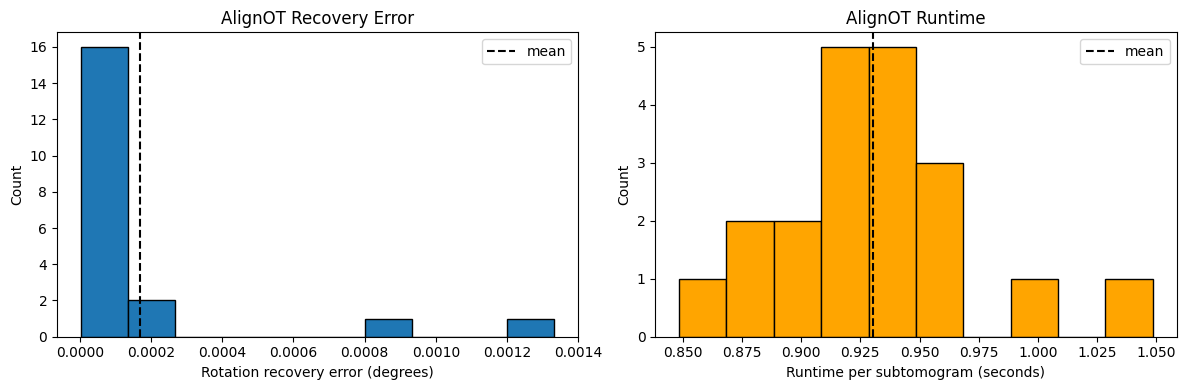

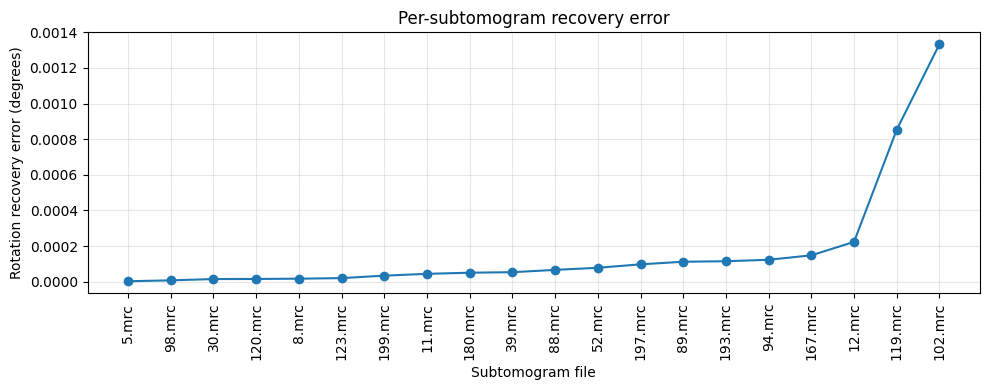

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(results_df["error_deg"], bins=min(10, len(results_df)), color="C0", edgecolor="black")
axes[0].axvline(results_df["error_deg"].mean(), color="black", linestyle="--", label="mean")
axes[0].set_xlabel("Rotation recovery error (degrees)")
axes[0].set_ylabel("Count")
axes[0].set_title("AlignOT Recovery Error")
axes[0].legend()

axes[1].hist(results_df["runtime_sec"], bins=min(10, len(results_df)), color="orange", edgecolor="black")
axes[1].axvline(results_df["runtime_sec"].mean(), color="black", linestyle="--", label="mean")
axes[1].set_xlabel("Runtime per subtomogram (seconds)")
axes[1].set_ylabel("Count")
axes[1].set_title("AlignOT Runtime")
axes[1].legend()

plt.tight_layout()
plt.show()

plot_df = results_df.sort_values("error_deg").reset_index(drop=True)
plt.figure(figsize=(10, 4))
plt.plot(plot_df["file"], plot_df["error_deg"], marker="o")
plt.xticks(rotation=90)
plt.xlabel("Subtomogram file")
plt.ylabel("Rotation recovery error (degrees)")
plt.title("Per-subtomogram recovery error")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
